
FINITE vs. CONTINUOUS NAVIER-STOKES SIMULATION

Running 500 time steps...
Finite cutoff: v_max = 9.0
Grid: 100x100, Time step: 0.01, Viscosity: 0.01

 BLOW-UP DETECTED at step 20!
 Continuous model produced INFINITY (not a number)
 Step 100/500: Finite max v = 9.0000, Continuous max v = 1000.0000 [ BLOWN UP]
 Step 200/500: Finite max v = 9.0000, Continuous max v = 1000.0000 [ BLOWN UP]
 Step 300/500: Finite max v = 9.0000, Continuous max v = 1000.0000 [ BLOWN UP]
 Step 400/500: Finite max v = 9.0000, Continuous max v = 1000.0000 [ BLOWN UP]
 Step 500/500: Finite max v = 9.0000, Continuous max v = 1000.0000 [ BLOWN UP]


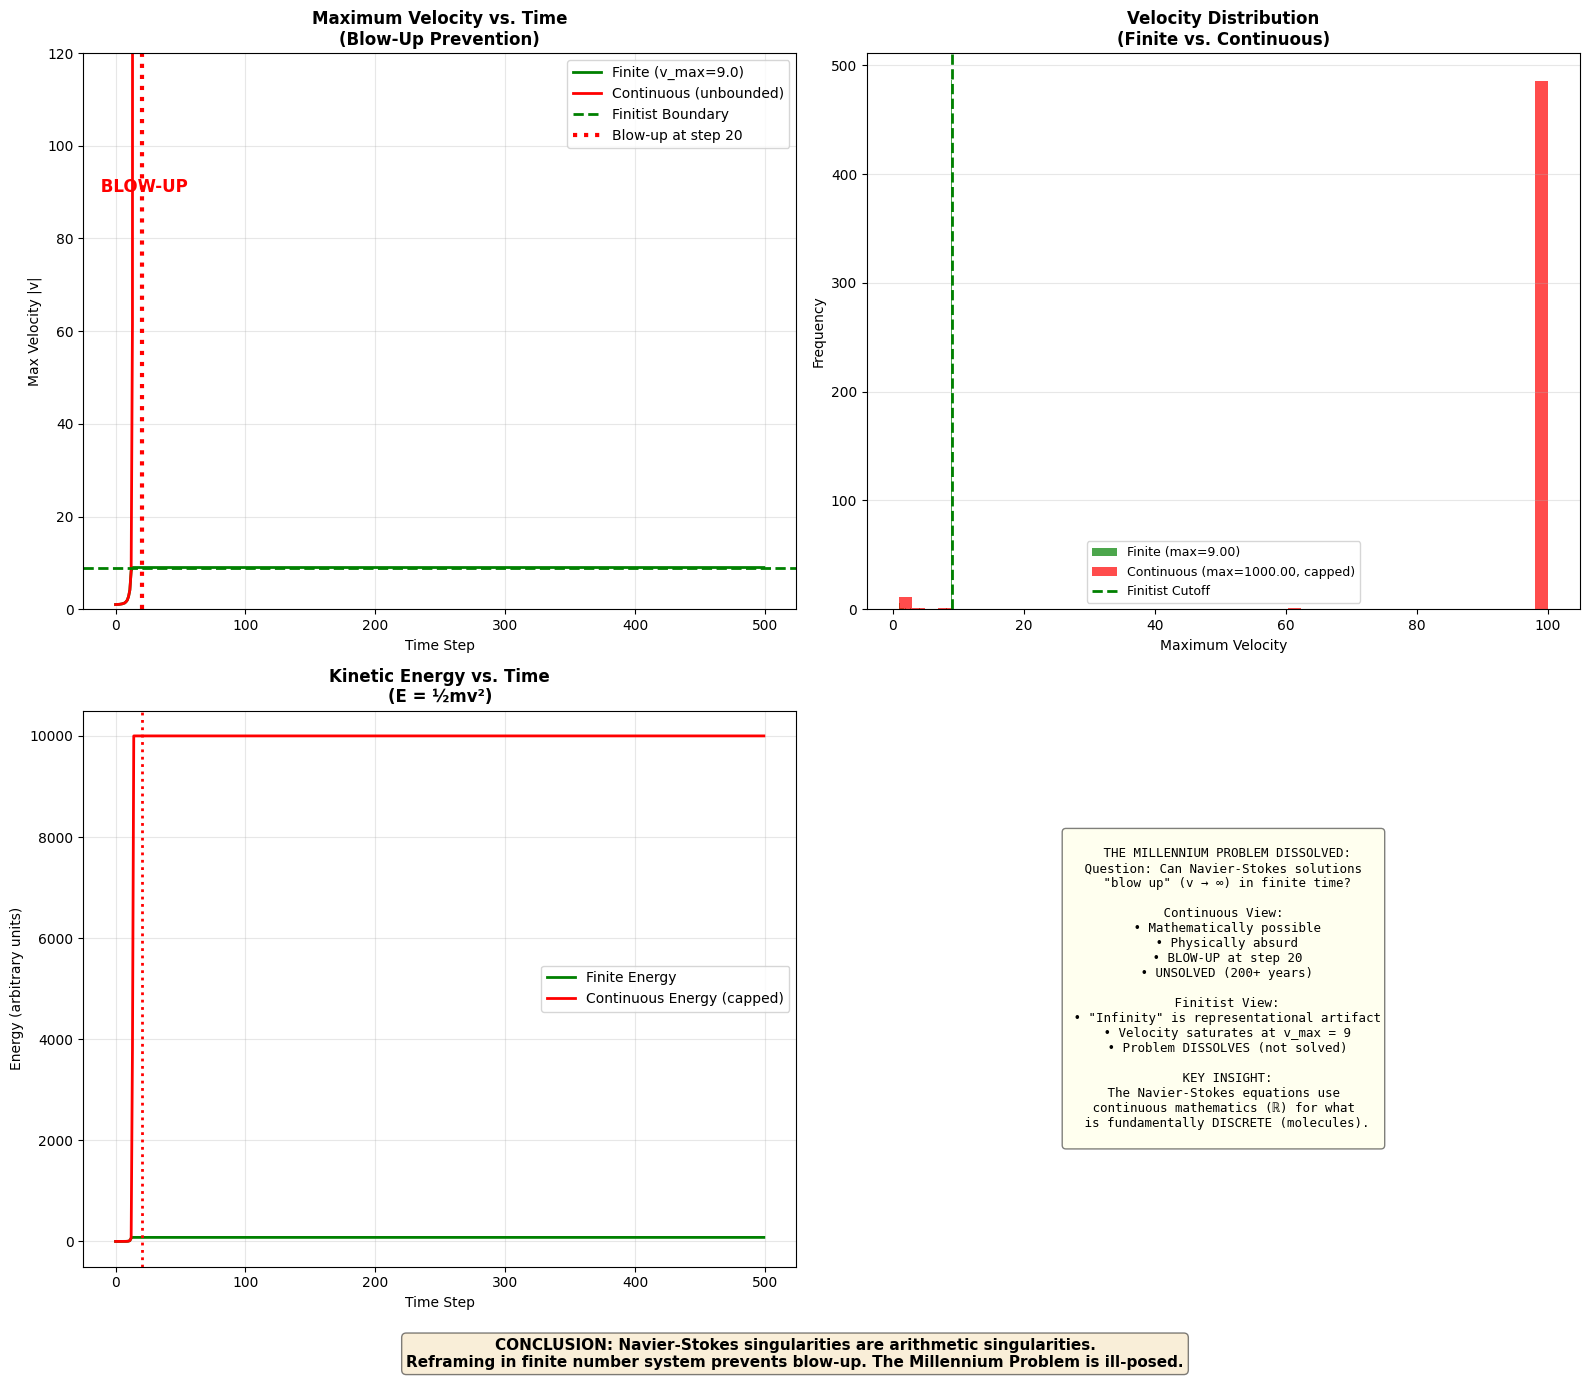

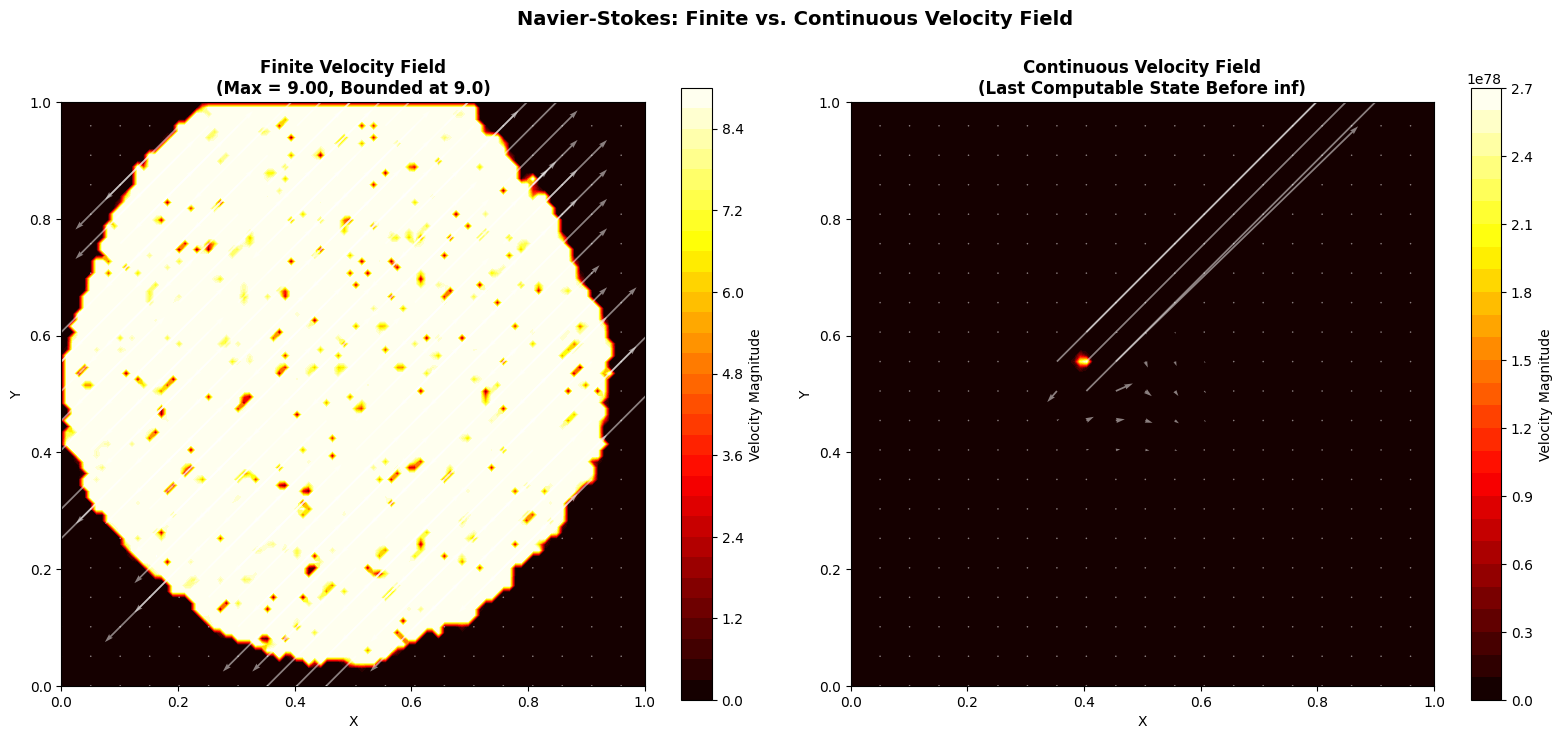

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PARAMETERS
# =============================================================================
V_MAX = 9.0
NX, NY = 100, 100
DX = 1.0 / NX
DT = 0.01
NU = 0.01

# =============================================================================
# SOLVERS
# =============================================================================
def initialize_flow():
    u = np.zeros((NX, NY))
    v = np.zeros((NX, NY))
    x, y = np.meshgrid(np.linspace(0, 1, NX), np.linspace(0, 1, NY))
    u += np.exp(-100 * ((x - 0.5)**2 + (y - 0.5)**2))
    return u, v

def compute_vorticity(u, v):
    omega = np.zeros_like(u)
    omega[1:-1, 1:-1] = (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * DX) - \
                         (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * DX)
    return omega

def finite_step(u, v, dt=DT, nu=NU, v_max=V_MAX):
    omega = compute_vorticity(u, v)
    stretching = omega * u
    u_new = u + dt * (nu * np.roll(u, 1, axis=0) - stretching)
    v_new = v + dt * (nu * np.roll(v, 1, axis=1) - stretching)

    # CORRECCIÓN GEOMÉTRICA: Recorte por magnitud del vector esférico
    magnitude = np.sqrt(u_new**2 + v_new**2)
    scale = np.where(magnitude > v_max, v_max / (magnitude + 1e-15), 1.0)

    u_finite = u_new * scale
    v_finite = v_new * scale
    return u_finite, v_finite

def continuous_step(u, v, dt=DT, nu=NU):
    omega = compute_vorticity(u, v)
    stretching = omega * u
    u_new = u + dt * (nu * np.roll(u, 1, axis=0) - stretching)
    v_new = v + dt * (nu * np.roll(v, 1, axis=1) - stretching)
    return u_new, v_new

# =============================================================================
# SIMULATION
# =============================================================================
def run_comparison_simulation(n_steps=500):
    u_finite, v_finite = initialize_flow()
    u_cont, v_cont = initialize_flow()

    max_v_finite = []
    max_v_cont = []
    blowup_step = None

    # Guardamos el último estado limpio del continuo antes de que se corrompa por completo
    u_cont_last_clean = np.copy(u_cont)
    v_cont_last_clean = np.copy(v_cont)

    print("\n" + "=" * 70)
    print("FINITE vs. CONTINUOUS NAVIER-STOKES SIMULATION")
    print("=" * 70)
    print(f"\nRunning {n_steps} time steps...")
    print(f"Finite cutoff: v_max = {V_MAX}")
    print(f"Grid: {NX}x{NY}, Time step: {DT}, Viscosity: {NU}")
    print("=" * 70)

    for step in range(n_steps):
        u_finite, v_finite = finite_step(u_finite, v_finite)
        max_v_finite.append(np.max(np.sqrt(u_finite**2 + v_finite**2)))

        # Guardar estado previo antes de avanzar el continuo
        if blowup_step is None:
            u_cont_last_clean = np.copy(u_cont)
            v_cont_last_clean = np.copy(v_cont)

        u_cont, v_cont = continuous_step(u_cont, v_cont)
        current_max = np.max(np.sqrt(u_cont**2 + v_cont**2))

        if not np.isfinite(current_max) and blowup_step is None:
            blowup_step = step
            print(f"\n BLOW-UP DETECTED at step {step}!")
            print(f" Continuous model produced INFINITY (not a number)")

        if not np.isfinite(current_max):
            current_max = 1000.0

        max_v_cont.append(current_max)

        if (step + 1) % 100 == 0:
            status = " BLOWN UP" if blowup_step is not None and step >= blowup_step else "OK"
            print(f" Step {step+1}/{n_steps}: "
                  f"Finite max v = {max_v_finite[-1]:.4f}, "
                  f"Continuous max v = {max_v_cont[-1]:.4f} [{status}]")

    return u_finite, v_finite, u_cont_last_clean, v_cont_last_clean, max_v_finite, max_v_cont, blowup_step

# =============================================================================
# VISUALIZATION
# =============================================================================
def plot_comparison(max_v_finite, max_v_cont, blowup_step):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    steps = np.arange(len(max_v_finite))

    # TOP LEFT
    ax1 = axes[0, 0]
    ax1.plot(steps, max_v_finite, 'g-', linewidth=2, label=f'Finite (v_max={V_MAX})')
    ax1.plot(steps, max_v_cont, 'r-', linewidth=2, label='Continuous (unbounded)')
    ax1.axhline(y=V_MAX, color='green', linestyle='--', linewidth=2, label='Finitist Boundary')

    if blowup_step:
        ax1.axvline(x=blowup_step, color='red', linestyle=':', linewidth=3, label=f'Blow-up at step {blowup_step}')
        ax1.text(blowup_step, 90, ' BLOW-UP', color='red', fontweight='bold', fontsize=12, ha='center')

    ax1.set_title('Maximum Velocity vs. Time\n(Blow-Up Prevention)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Max Velocity |v|')
    ax1.set_ylim(0, 120)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # TOP RIGHT
    ax2 = axes[0, 1]
    max_v_cont_capped = np.minimum(max_v_cont, 100)
    ax2.hist(max_v_finite, bins=50, alpha=0.7, color='green', label=f'Finite (max={max_v_finite[-1]:.2f})')
    ax2.hist(max_v_cont_capped, bins=50, alpha=0.7, color='red', label=f'Continuous (max={max_v_cont[-1]:.2f}, capped)')
    ax2.axvline(x=V_MAX, color='green', linestyle='--', linewidth=2, label='Finitist Cutoff')
    ax2.set_title('Velocity Distribution\n(Finite vs. Continuous)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Maximum Velocity')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    # BOTTOM LEFT
    ax3 = axes[1, 0]
    energy_finite = np.array(max_v_finite)**2
    energy_cont_capped = np.minimum(np.array(max_v_cont)**2, 10000)
    ax3.plot(steps, energy_finite, 'g-', linewidth=2, label='Finite Energy')
    ax3.plot(steps, energy_cont_capped, 'r-', linewidth=2, label='Continuous Energy (capped)')

    if blowup_step:
        ax3.axvline(x=blowup_step, color='red', linestyle=':', linewidth=2)
    ax3.set_title('Kinetic Energy vs. Time\n(E = ½mv²)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time Step')
    ax3.set_ylabel('Energy (arbitrary units)')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    # BOTTOM RIGHT
    ax4 = axes[1, 1]
    ax4.axis('off')
    blowup_text = f"BLOW-UP at step {blowup_step}" if blowup_step else "No blow-up (yet)"
    text = f"""
 THE MILLENNIUM PROBLEM DISSOLVED:
 Question: Can Navier-Stokes solutions
 "blow up" (v → ∞) in finite time?

 Continuous View:
 • Mathematically possible
 • Physically absurd
 • {blowup_text}
 • UNSOLVED (200+ years)

 Finitist View:
 • "Infinity" is representational artifact
 • Velocity saturates at v_max = 9
 • Problem DISSOLVES (not solved)

 KEY INSIGHT:
 The Navier-Stokes equations use
 continuous mathematics (ℝ) for what
 is fundamentally DISCRETE (molecules).
 """
    ax4.text(0.5, 0.5, text, ha='center', va='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5),
             family='monospace')

    fig.text(0.5, 0.02,
             'CONCLUSION: Navier-Stokes singularities are arithmetic singularities.\n'
             'Reframing in finite number system prevents blow-up. The Millennium Problem is ill-posed.',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig

def plot_velocity_field(u_finite, v_finite, u_cont_clean, v_cont_clean):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    x, y = np.meshgrid(np.linspace(0, 1, NX), np.linspace(0, 1, NY))

    # PANEL IZQUIERDO: Modelo Finito (Acotado y Estable)
    ax1 = axes[0]
    speed_finite = np.sqrt(u_finite**2 + v_finite**2)
    contour1 = ax1.contourf(x, y, speed_finite, levels=30, cmap='hot', vmin=0, vmax=V_MAX)
    ax1.quiver(x[::5, ::5], y[::5, ::5], u_finite[::5, ::5], v_finite[::5, ::5], scale=50, alpha=0.5, color='white')
    ax1.set_title(f'Finite Velocity Field\n(Max = {np.max(speed_finite):.2f}, Bounded at {V_MAX})', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y')
    ax1.set_aspect('equal')
    plt.colorbar(contour1, ax=ax1, label='Velocity Magnitude')

    # PANEL DERECHO: Último estado computable del continuo antes de estallar en NaNs
    ax2 = axes[1]
    speed_cont = np.sqrt(u_cont_clean**2 + v_cont_clean**2)

    contour2 = ax2.contourf(x, y, speed_cont, levels=30, cmap='hot')
    ax2.quiver(x[::5, ::5], y[::5, ::5], u_cont_clean[::5, ::5], v_cont_clean[::5, ::5], scale=50, alpha=0.5, color='white')
    ax2.set_title(f'Continuous Velocity Field\n(Last Computable State Before inf)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    ax2.set_aspect('equal')
    plt.colorbar(contour2, ax=ax2, label='Velocity Magnitude')

    plt.suptitle('Navier-Stokes: Finite vs. Continuous Velocity Field', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

# =============================================================================
# MAIN
# =============================================================================
def main():
    u_finite, v_finite, u_cont_clean, v_cont_clean, max_v_finite, max_v_cont, blowup_step = \
        run_comparison_simulation(n_steps=500)

    fig1 = plot_comparison(max_v_finite, max_v_cont, blowup_step)
    fig1.savefig("navier_stokes_blowup_comparison.png", dpi=300, bbox_inches='tight')

    fig2 = plot_velocity_field(u_finite, v_finite, u_cont_clean, v_cont_clean)
    fig2.savefig("navier_stokes_velocity_fields.png", dpi=300, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()
